## Randon Forest - Decision Tree Classification and Regression

In [2]:
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import pandas as pd

df = pd.read_csv("../../data/Heart.csv", index_col=0)
df.head()


,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 303 entries, 1 to 303
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        303 non-null    int64  
 1   Sex        303 non-null    int64  
 2   ChestPain  303 non-null    object 
 3   RestBP     303 non-null    int64  
 4   Chol       303 non-null    int64  
 5   Fbs        303 non-null    int64  
 6   RestECG    303 non-null    int64  
 7   MaxHR      303 non-null    int64  
 8   ExAng      303 non-null    int64  
 9   Oldpeak    303 non-null    float64
 10  Slope      303 non-null    int64  
 11  Ca         299 non-null    float64
 12  Thal       301 non-null    object 
 13  AHD        303 non-null    object 
dtypes: float64(2), int64(9), object(3)
memory usage: 35.5+ KB


<Axes: xlabel='AHD', ylabel='count'>

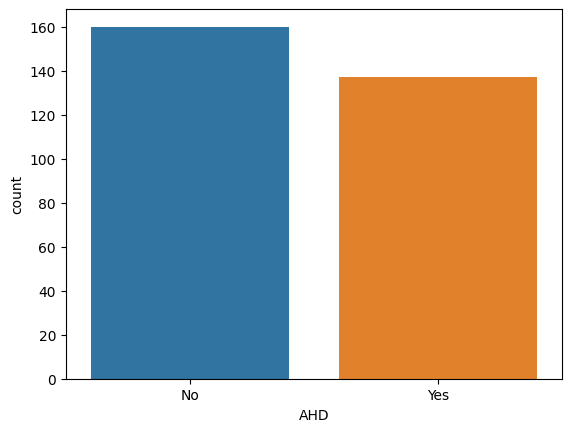

In [11]:
df.dropna(inplace=True) #drop any null values to clean data set

sns.countplot(data=df, x= "AHD", hue= "AHD")

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 1 to 302
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        297 non-null    int64  
 1   Sex        297 non-null    int64  
 2   ChestPain  297 non-null    object 
 3   RestBP     297 non-null    int64  
 4   Chol       297 non-null    int64  
 5   Fbs        297 non-null    int64  
 6   RestECG    297 non-null    int64  
 7   MaxHR      297 non-null    int64  
 8   ExAng      297 non-null    int64  
 9   Oldpeak    297 non-null    float64
 10  Slope      297 non-null    int64  
 11  Ca         297 non-null    float64
 12  Thal       297 non-null    object 
 13  AHD        297 non-null    object 
dtypes: float64(2), int64(9), object(3)
memory usage: 34.8+ KB


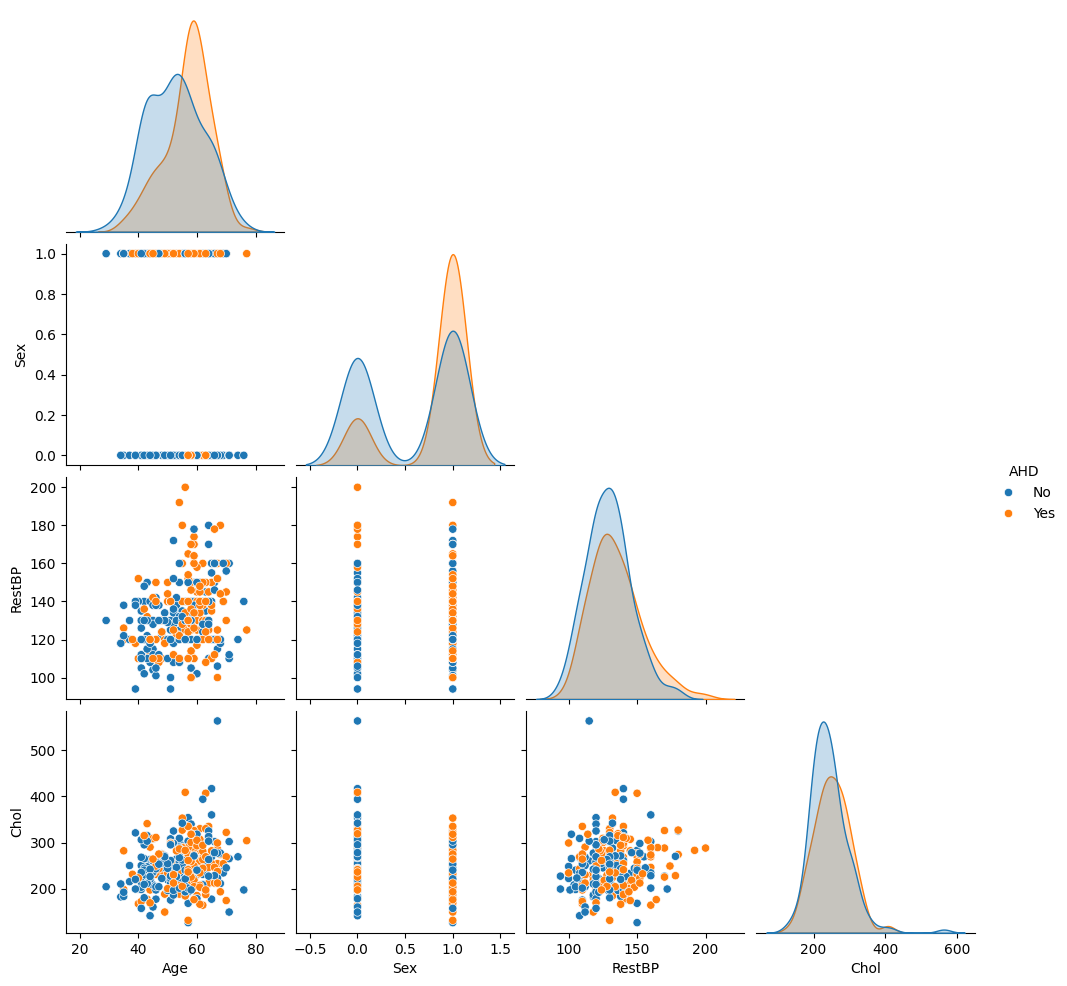

In [16]:
# feature engineering to look at correlations through heat map or pairplot
# Target variable is AHD= Yes/No and its correlation to numerical features
# consider Thal and ChestPain as categorical predictors
# make pairplot to explore

sns.pairplot(
    data = df[["Age", "Sex", "RestBP", "Chol",  "AHD"]],
    corner= True,
    hue= "AHD",
    palette="tab10"
)

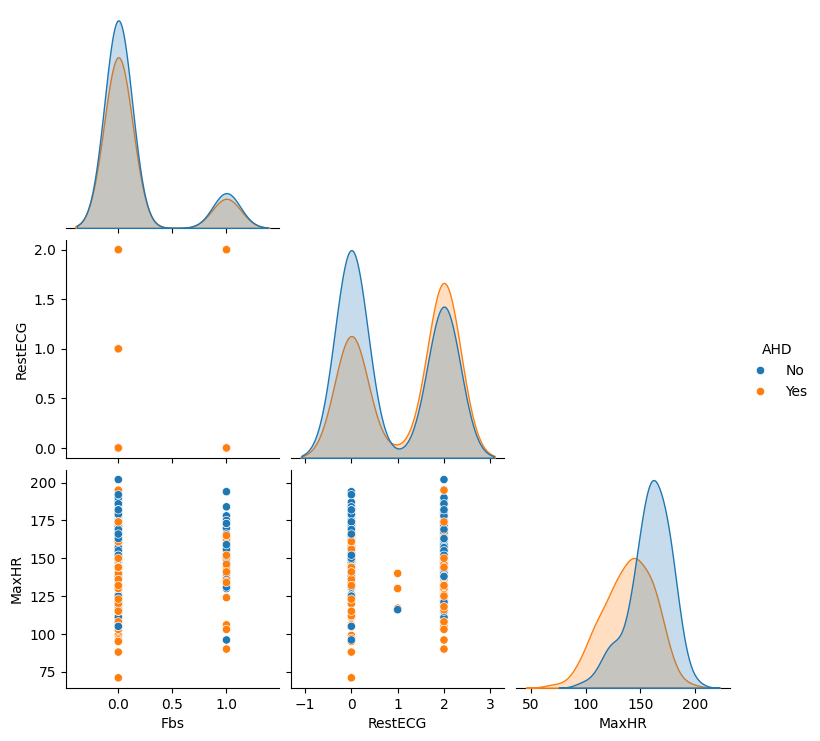

In [20]:
sns.pairplot(
    data=df[["Fbs", "RestECG", "MaxHR","AHD"]],
    corner=True,
    hue="AHD",
    palette="tab10",
)



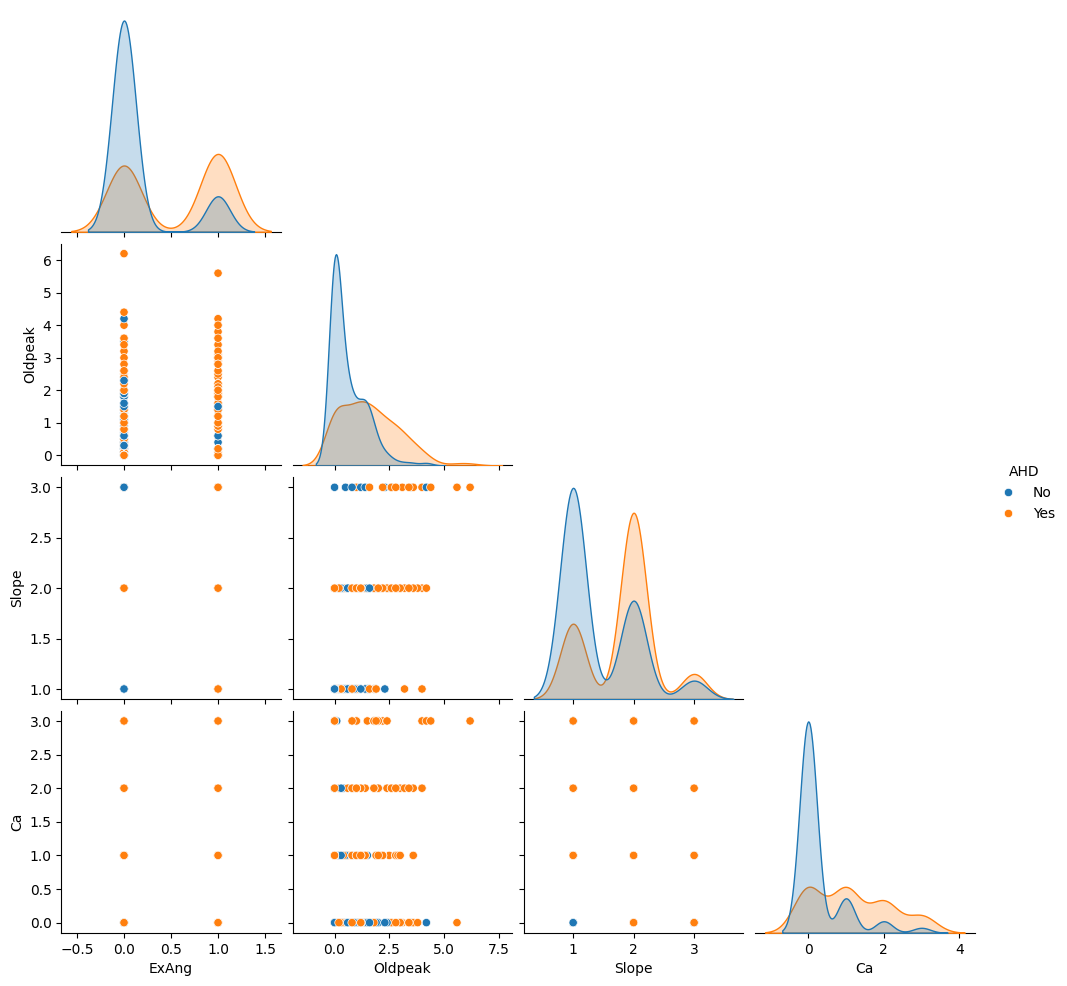

In [21]:
sns.pairplot( 
    data=df[["ExAng", "Oldpeak", "Slope", "Ca", "AHD"]],
    corner=True,
    hue= "AHD",
    palette="tab10"
    )


In [32]:
df.corr

<bound method DataFrame.corr of      Age  Sex     ChestPain  RestBP  Chol  Fbs  RestECG  MaxHR  ExAng  \
1     63    1       typical     145   233    1        2    150      0   
2     67    1  asymptomatic     160   286    0        2    108      1   
3     67    1  asymptomatic     120   229    0        2    129      1   
4     37    1    nonanginal     130   250    0        0    187      0   
5     41    0    nontypical     130   204    0        2    172      0   
..   ...  ...           ...     ...   ...  ...      ...    ...    ...   
299   45    1       typical     110   264    0        0    132      0   
300   68    1  asymptomatic     144   193    1        0    141      0   
301   57    1  asymptomatic     130   131    0        0    115      1   
302   57    0    nontypical     130   236    0        2    174      0   
303   38    1    nonanginal     138   175    0        0    173      0   

     Oldpeak  Slope   Ca        Thal  AHD  
1        2.3      3  0.0       fixed   No  
2  

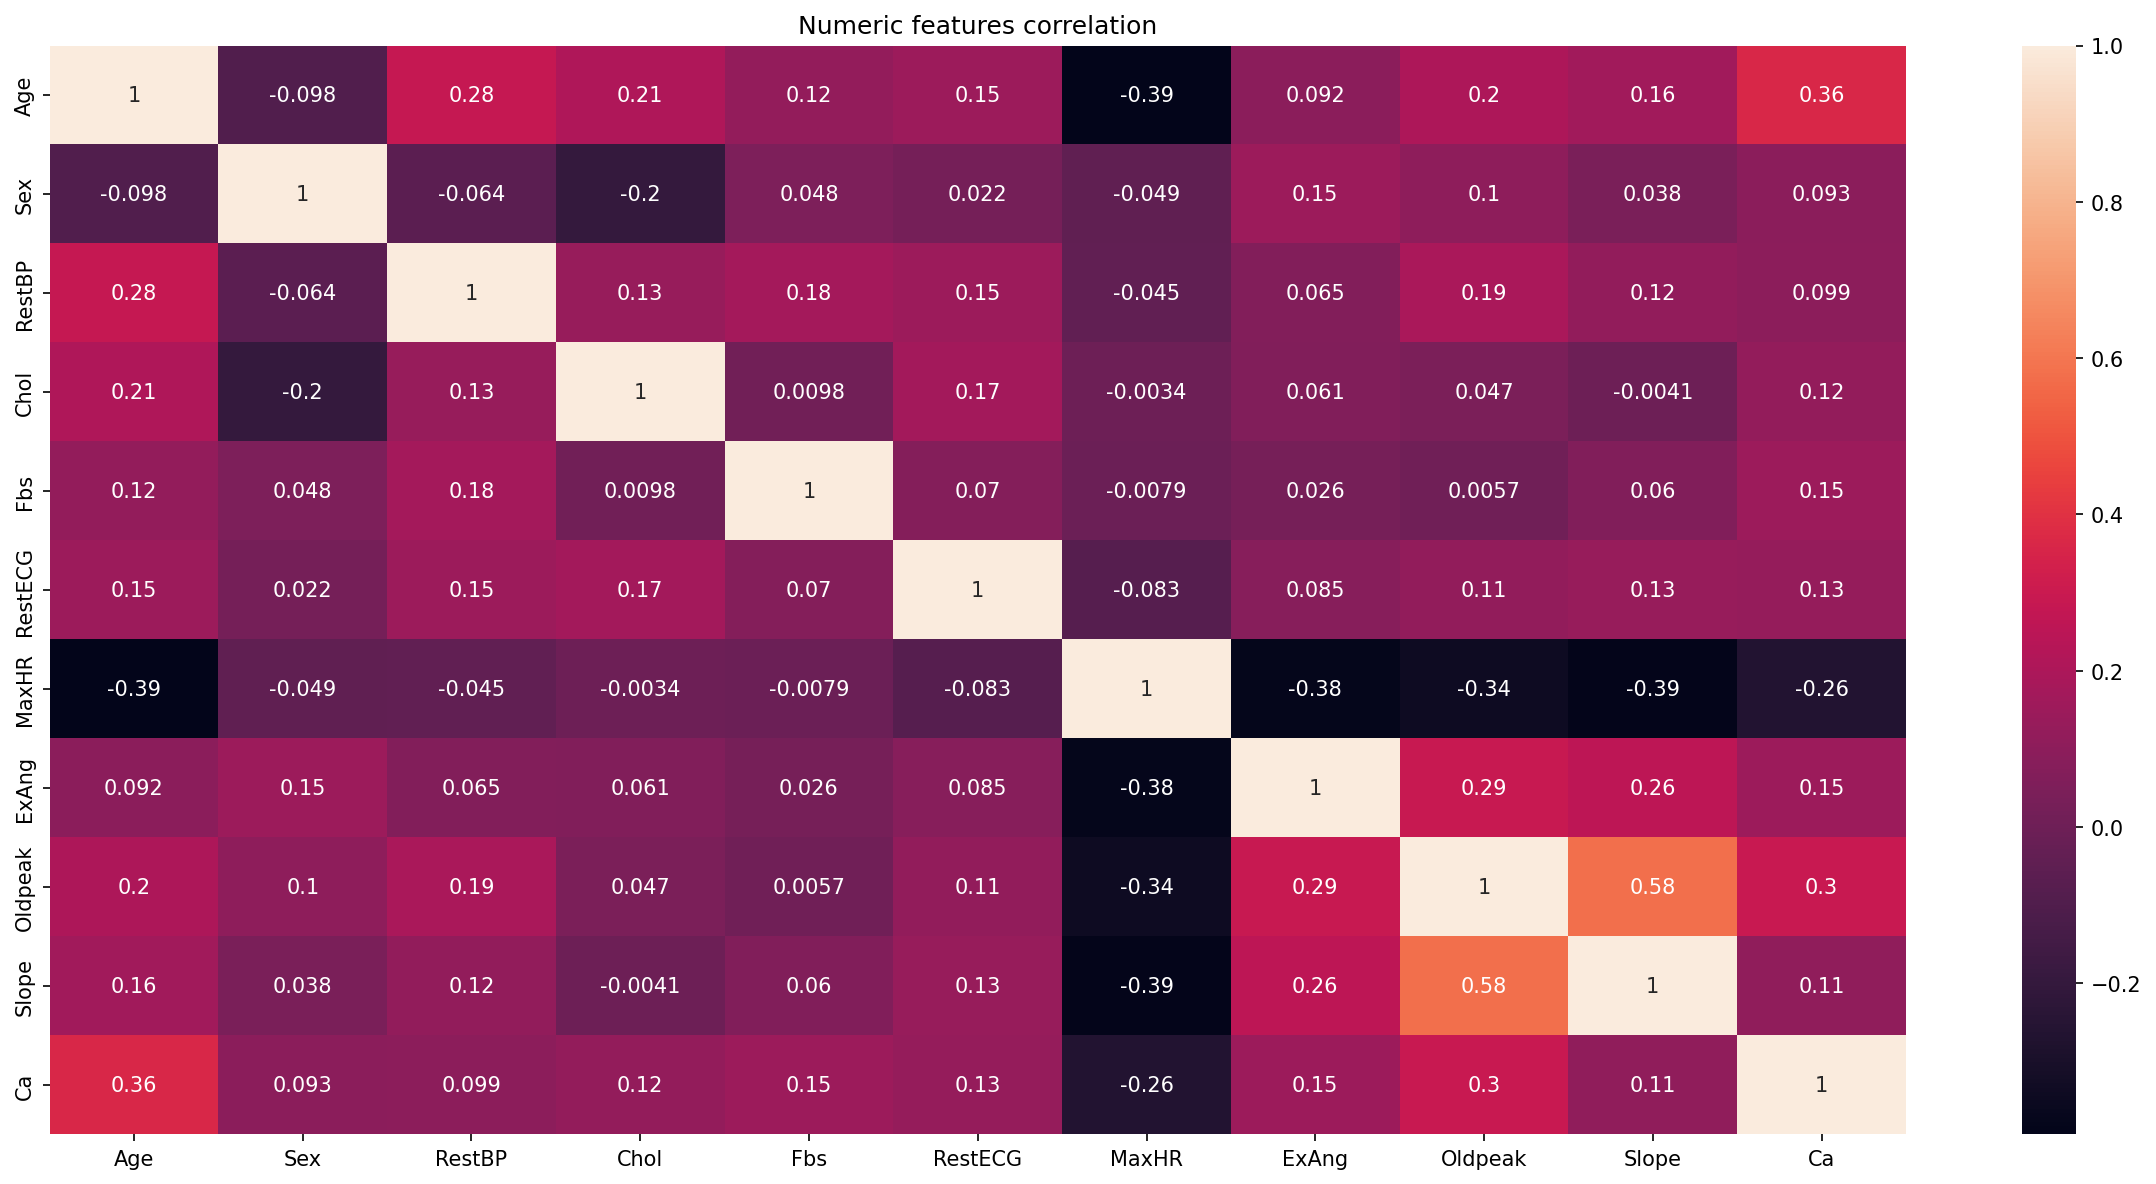

In [4]:
# heatmap
import matplotlib.pyplot as plt
import numpy as np

# first, exclude categorical columns so plot only on numeric
corr = df.corr(numeric_only=True)

fig, ax=plt.subplots(1, figsize=(16, 8), dpi= 150)
sns.heatmap(corr, annot=True, ax=ax)
plt.title("Numeric features correlation")
plt.tight_layout()
plt.show()

In [5]:
#include object dtypes ie Thal, AHD and ChestPain
# AHD is Yes/No so 1/0
df["AHD"] = df["AHD"].map({"Yes": 1, "No":0})
df.head()

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,0
2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,1
3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,1
4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,0
5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,0


In [6]:
# ChestPain, Thal -> numbers
# dummy encoding -> 1/0
df_dummy = pd.get_dummies(df, columns=["ChestPain", "Thal"], drop_first=True)
df_dummy.head()


,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,AHD,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical,Thal_normal,Thal_reversable
1,63,1,145,233,1,2,150,0,2.3,3,0.0,0,False,False,True,False,False
2,67,1,160,286,0,2,108,1,1.5,2,3.0,1,False,False,False,True,False
3,67,1,120,229,0,2,129,1,2.6,2,2.0,1,False,False,False,False,True
4,37,1,130,250,0,0,187,0,3.5,3,0.0,0,True,False,False,True,False
5,41,0,130,204,0,2,172,0,1.4,1,0.0,0,False,True,False,True,False


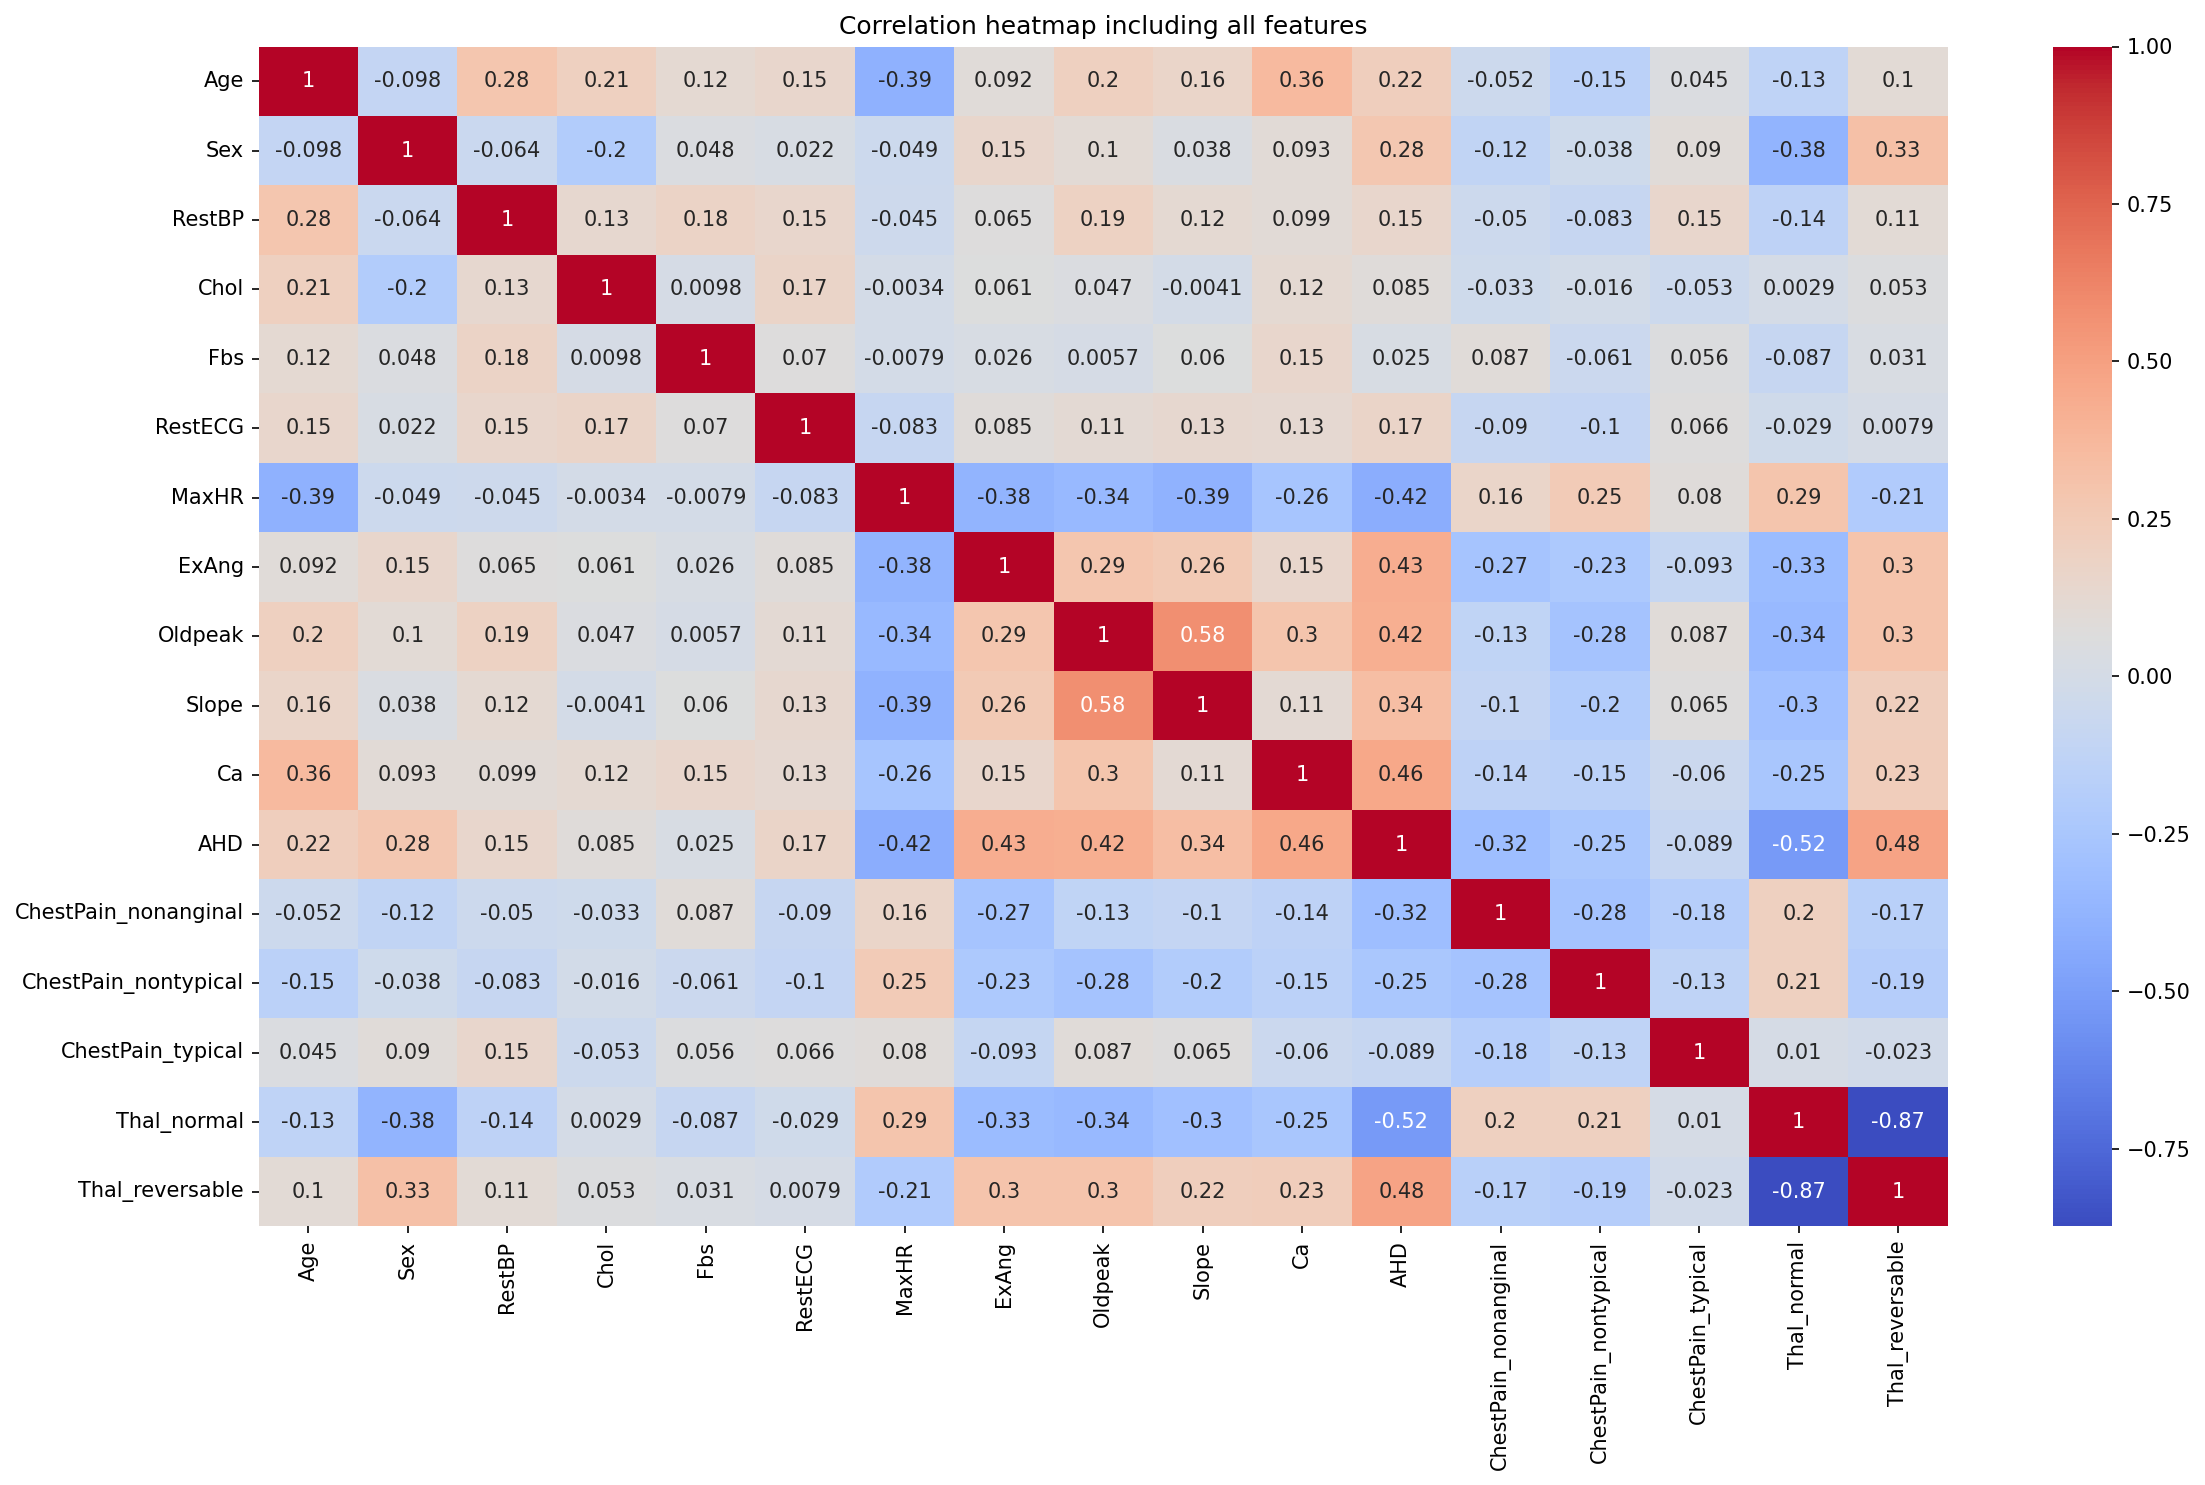

In [9]:
corr = df_dummy.corr()

plt.figure(figsize=(16, 10), dpi=150)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation heatmap including all features")
plt.tight_layout()
plt.show()

In [11]:
# print list of correlations desc
# conclusions: Thal_revers, Ca, ExAng, OldPeak are high correlations to AHD 
# ie these are predictive signals that show association

corr_AHD = corr["AHD"].sort_values(ascending=False)
print(corr_AHD)

AHD                     1.000000
Thal_reversable         0.480582
Ca                      0.460442
ExAng                   0.431894
Oldpeak                 0.424510
Slope                   0.339213
Sex                     0.276816
Age                     0.223120
RestECG                 0.169202
RestBP                  0.150825
Chol                    0.085164
Fbs                     0.025264
ChestPain_typical      -0.088806
ChestPain_nontypical   -0.248683
ChestPain_nonanginal   -0.315141
MaxHR                  -0.417167
Thal_normal            -0.521016
Name: AHD, dtype: float64


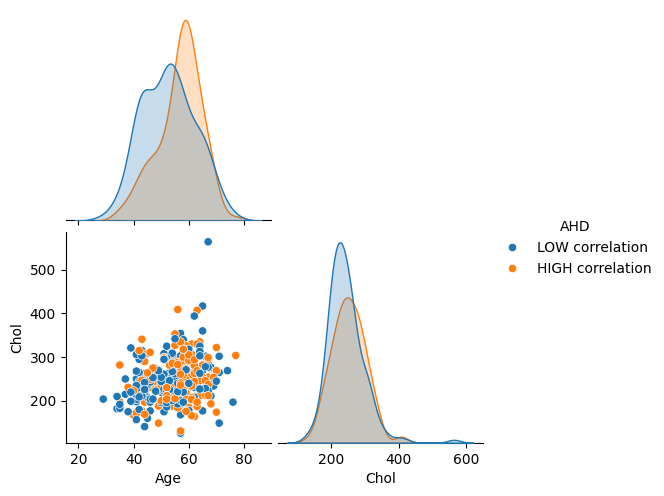

In [15]:
# check clusters of certain combinations:
# age vs col coloured by AHD
df["AHD"] = df["AHD"].map({0: "LOW correlation", 1: "HIGH correlation"})
sns.pairplot(
    data = df[["Age", "Chol", "AHD"]],
    corner= True,
    hue= "AHD",
    palette="tab10"
)

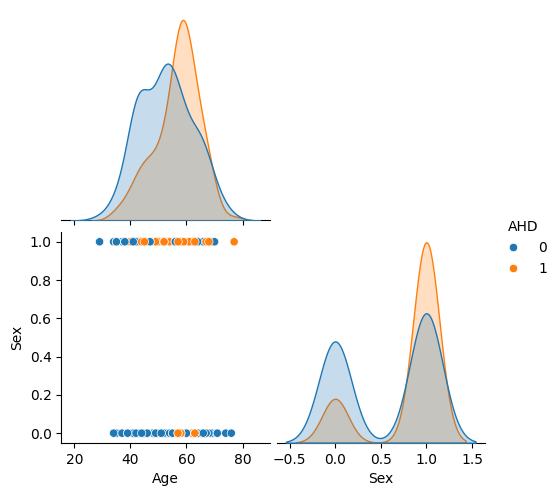

In [13]:
# Age vs Sex -> AHD
sns.pairplot(
    data = df[["Age", "Sex", "AHD"]],
    corner= True,
    hue= "AHD",
    palette="tab10"
)

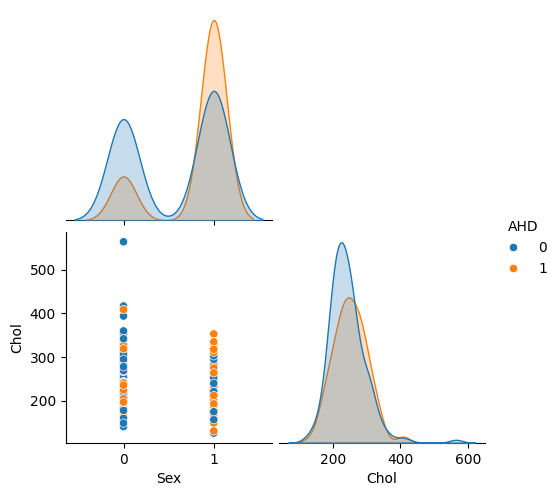

In [14]:
# Chol vs Sex -> AHD
# convert sex from 0/1 to M/F
sns.pairplot(
    data = df[["Sex", "Chol", "AHD"]],
    corner= True,
    hue= "AHD",
    palette="tab10"
)